<a href="https://colab.research.google.com/github/MODPDS/aqualimpia-analisis-datos/blob/main/Patricio_D%C3%ADaz_Unidad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Celda 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurar el estilo de las visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Librerías importadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

 Librerías importadas correctamente
Pandas version: 2.2.2
Matplotlib version: 3.10.0


In [2]:
# Celda 2: Cargar el dataset y exploración inicial

# Cargar el archivo Excel
df = pd.read_excel('dataset_set_A_aguas_residuales.xlsx')

print("=" * 50)
print(" EXPLORACIÓN INICIAL DEL DATASET")
print("=" * 50)

# 1. Ver primeras filas
print("\n🔹 PRIMERAS 5 FILAS:")
print(df.head())

# 2. Ver información general
print("\n🔹 INFORMACIÓN DEL DATASET:")
print(df.info())

# 3. Ver estadísticas descriptivas
print("\n🔹 ESTADÍSTICAS DESCRIPTIVAS:")
print(df.describe())

# 4. Verificar valores faltantes
print("\n🔹 VALORES FALTANTES POR COLUMNA:")
print(df.isnull().sum())

# 5. Ver dimensión del dataset
print(f"\n🔹 DIMENSIÓN: {df.shape[0]} filas y {df.shape[1]} columnas")

 EXPLORACIÓN INICIAL DEL DATASET

🔹 PRIMERAS 5 FILAS:
  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-08-17     Planta Sur                 6562               271   
1     2025-09-07     Planta Sur                 5336               322   
2     2025-07-26   Planta Norte                 5755               318   
3     2025-10-27  Planta Centro                 6840               216   
4     2025-09-06  Planta Centro                 6803               326   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               324        7.12                1261.1                 440.3   
1               230        7.01                1629.3                 561.2   
2               282        6.79                1469.2                 441.6   
3               167        7.01                1764.8                 560.0   
4               200        7.55                1409.3                 654.0   

   DBO_salida_mg_L  cumpli

In [3]:
# Celda 3: Preparación de datos (limpieza y transformaciones básicas)

# Convertir fecha_registro a tipo datetime
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

# Verificar la conversión
print("Fechas convertidas correctamente")
print(f"Rango de fechas: {df['fecha_registro'].min()} hasta {df['fecha_registro'].max()}")

# Ver tipos de datos actualizados
print("\n🔹 TIPOS DE DATOS ACTUALIZADOS:")
print(df.dtypes)

# Mostrar resumen por planta
print("\n🔹 RESÚMEN POR PLANTA:")
resumen_plantas = df.groupby('planta').size()
print(resumen_plantas)

Fechas convertidas correctamente
Rango de fechas: 2025-07-01 00:00:00 hasta 2025-10-28 00:00:00

🔹 TIPOS DE DATOS ACTUALIZADOS:
fecha_registro          datetime64[ns]
planta                          object
caudal_entrada_m3_d              int64
DBO_entrada_mg_L                 int64
SST_entrada_mg_L                 int64
pH_entrada                     float64
energia_aeracion_kWh           float64
lodos_generados_kg_d           float64
DBO_salida_mg_L                float64
cumplimiento_norma               int64
dtype: object

🔹 RESÚMEN POR PLANTA:
planta
Planta Centro    75
Planta Norte     71
Planta Sur       54
dtype: int64


In [4]:
# Celda 4: Funciones modulares para el análisis

def calcular_eficiencia(df):
    """
    Calcula la eficiencia de remoción de DBO y genera alertas operativas.

    Fórmula de eficiencia: ((DBO_entrada - DBO_salida) / DBO_entrada) * 100
    """
    # Calcular eficiencia
    df['eficiencia_dbo'] = ((df['DBO_entrada_mg_L'] - df['DBO_salida_mg_L']) / df['DBO_entrada_mg_L']) * 100

    # Generar alertas de eficiencia
    # Óptimo: >=85%, Atención: 70-85%, Crítico: <70%
    df['alerta_eficiencia'] = np.where(df['eficiencia_dbo'] >= 85, 'Óptimo',
                                       np.where(df['eficiencia_dbo'] >= 70, 'Atención', 'Crítico'))

    # Detectar caudal alto (percentil 95)
    caudal_limite = df['caudal_entrada_m3_d'].quantile(0.95)
    df['alerta_caudal'] = np.where(df['caudal_entrada_m3_d'] > caudal_limite,
                                   'Caudal Alto', 'Normal')

    print(" Eficiencia calculada y alertas generadas")
    print(f"   - Caudal límite para alerta (percentil 95): {caudal_limite:.0f} m³/día")

    return df

def exportar_reportes(df):
    """
    Exporta reportes diferenciados para el Área de Operaciones y Gestión Ambiental.
    """
    # Reporte para Operaciones (con alertas operativas)
    reporte_ops = df[['fecha_registro', 'planta', 'caudal_entrada_m3_d',
                      'DBO_entrada_mg_L', 'DBO_salida_mg_L',
                      'energia_aeracion_kWh', 'lodos_generados_kg_d',
                      'eficiencia_dbo', 'alerta_eficiencia', 'alerta_caudal']]

    # Reporte para Gestión Ambiental (enfoque en cumplimiento normativo)
    reporte_amb = df[['fecha_registro', 'planta', 'DBO_salida_mg_L', 'cumplimiento_norma',
                      'eficiencia_dbo']]

    # Guardar archivos Excel
    reporte_ops.to_excel('Reporte_Operaciones_Aqua.xlsx', index=False)
    reporte_amb.to_excel('Reporte_Ambiental_Aqua.xlsx', index=False)

    print("\n REPORTES EXPORTADOS EXITOSAMENTE")
    print(f"   - Reporte_Operaciones_Aqua.xlsx ({len(reporte_ops)} registros)")
    print(f"   - Reporte_Ambiental_Aqua.xlsx ({len(reporte_amb)} registros)")

    return reporte_ops, reporte_amb

# Aplicar la función de eficiencia al dataset
df = calcular_eficiencia(df)

# Mostrar un resumen de las nuevas columnas creadas
print("\n🔹 NUEVAS COLUMNAS AGREGADAS:")
print(f"   - eficiencia_dbo: {df['eficiencia_dbo'].min():.1f}% a {df['eficiencia_dbo'].max():.1f}%")
print(f"   - alerta_eficiencia: {df['alerta_eficiencia'].unique()}")
print(f"   - alerta_caudal: {df['alerta_caudal'].unique()}")

 Eficiencia calculada y alertas generadas
   - Caudal límite para alerta (percentil 95): 7155 m³/día

🔹 NUEVAS COLUMNAS AGREGADAS:
   - eficiencia_dbo: 80.7% a 93.4%
   - alerta_eficiencia: ['Óptimo' 'Atención']
   - alerta_caudal: ['Normal' 'Caudal Alto']


/tmp/ipykernel_728/3346310488.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='planta', y='eficiencia_dbo', ax=axes[0, 1], palette='Set2')


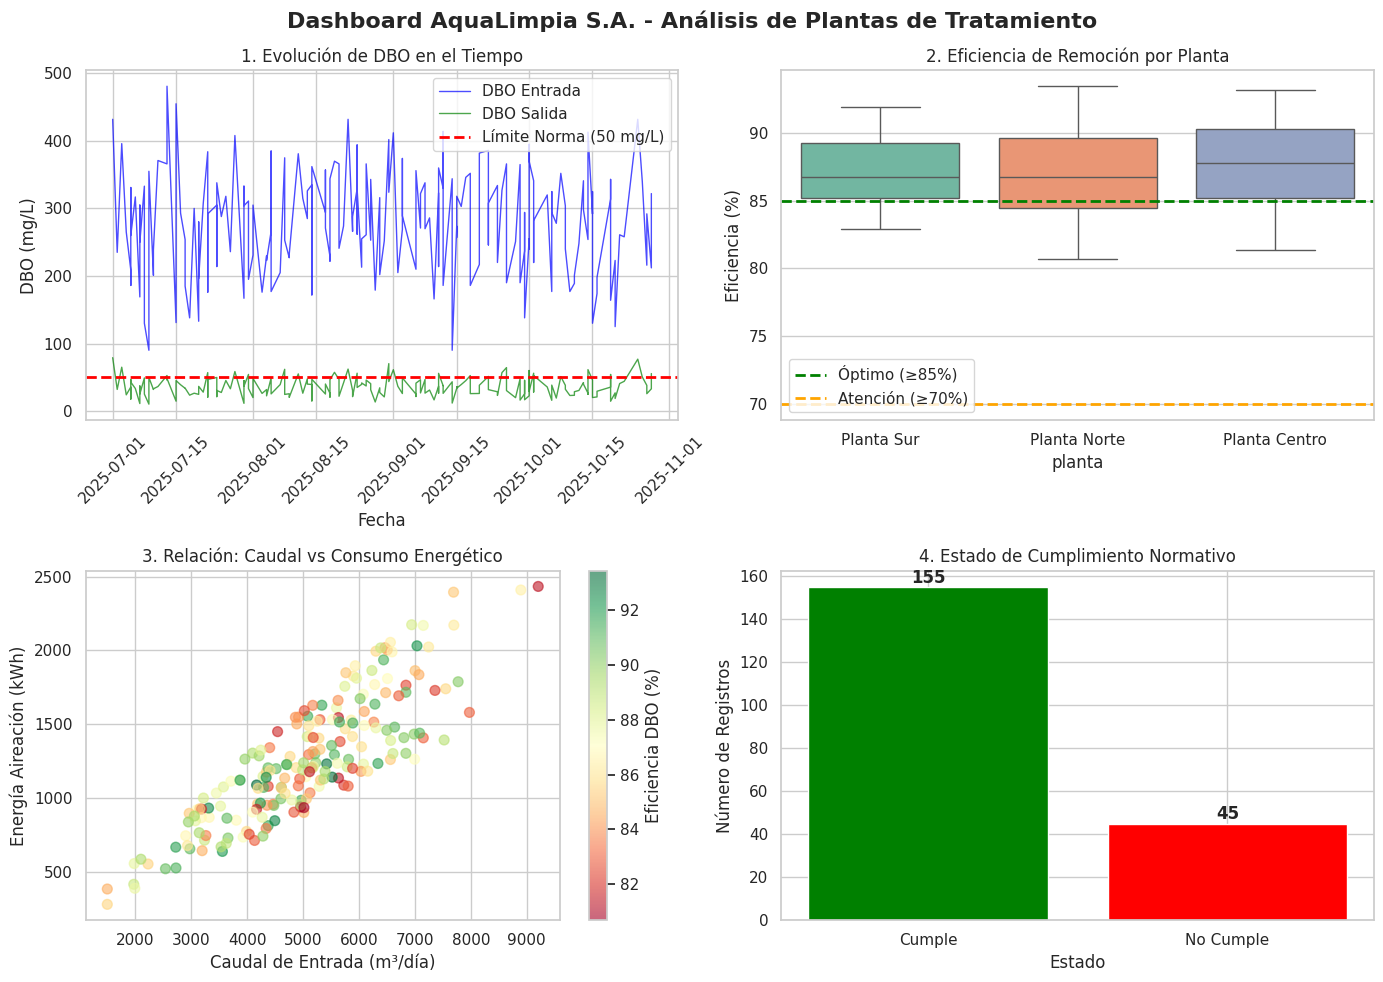


 ESTADÍSTICAS CLAVE DEL ANÁLISIS
 Tasa de cumplimiento normativo: 22.5%
 Eficiencia promedio de remoción DBO: 87.1%
 Eficiencia mínima: 80.7%
 Eficiencia máxima: 93.4%

 ALERTAS DE EFICIENCIA POR PLANTA:
alerta_eficiencia  Atención  Óptimo
planta                             
Planta Centro            18      57
Planta Norte             23      48
Planta Sur               12      42

 DISTRIBUCIÓN DE INCUMPLIMIENTOS POR PLANTA:
   Planta Norte: 59 de 71 registros (83.1%)
   Planta Centro: 58 de 75 registros (77.3%)
   Planta Sur: 38 de 54 registros (70.4%)


In [5]:
# Celda 5: Dashboard exploratorio

def crear_dashboard(df):
    """
    Crea un dashboard con 4 visualizaciones clave para el análisis de plantas.
    """
    # Crear figura con 2 filas y 2 columnas de gráficos
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Título principal del dashboard
    fig.suptitle('Dashboard AquaLimpia S.A. - Análisis de Plantas de Tratamiento',
                 fontsize=16, fontweight='bold')

    # ---------- GRÁFICO 1: Evolución de DBO en el tiempo ----------
    df_ordenado = df.sort_values('fecha_registro')

    axes[0, 0].plot(df_ordenado['fecha_registro'], df_ordenado['DBO_entrada_mg_L'],
                    label='DBO Entrada', alpha=0.7, color='blue', linewidth=1)
    axes[0, 0].plot(df_ordenado['fecha_registro'], df_ordenado['DBO_salida_mg_L'],
                    label='DBO Salida', alpha=0.7, color='green', linewidth=1)
    axes[0, 0].axhline(y=50, color='red', linestyle='--', linewidth=2,
                       label='Límite Norma (50 mg/L)')
    axes[0, 0].set_title('1. Evolución de DBO en el Tiempo', fontsize=12)
    axes[0, 0].set_xlabel('Fecha')
    axes[0, 0].set_ylabel('DBO (mg/L)')
    axes[0, 0].legend(loc='upper right')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # ---------- GRÁFICO 2: Eficiencia por planta (Boxplot) ----------
    sns.boxplot(data=df, x='planta', y='eficiencia_dbo', ax=axes[0, 1], palette='Set2')
    axes[0, 1].axhline(y=85, color='green', linestyle='--', linewidth=2,
                       label='Óptimo (≥85%)')
    axes[0, 1].axhline(y=70, color='orange', linestyle='--', linewidth=2,
                       label='Atención (≥70%)')
    axes[0, 1].set_title('2. Eficiencia de Remoción por Planta', fontsize=12)
    axes[0, 1].set_ylabel('Eficiencia (%)')
    axes[0, 1].legend()

    # ---------- GRÁFICO 3: Caudal vs Consumo Energético ----------
    scatter = axes[1, 0].scatter(df['caudal_entrada_m3_d'], df['energia_aeracion_kWh'],
                                 c=df['eficiencia_dbo'], cmap='RdYlGn', alpha=0.6, s=50)
    axes[1, 0].set_title('3. Relación: Caudal vs Consumo Energético', fontsize=12)
    axes[1, 0].set_xlabel('Caudal de Entrada (m³/día)')
    axes[1, 0].set_ylabel('Energía Aireación (kWh)')
    plt.colorbar(scatter, ax=axes[1, 0], label='Eficiencia DBO (%)')

    # ---------- GRÁFICO 4: Estado de Cumplimiento Normativo ----------
    cumple_counts = df['cumplimiento_norma'].value_counts()
    colores_barra = ['green', 'red']
    axes[1, 1].bar(['Cumple', 'No Cumple'], cumple_counts.values, color=colores_barra)
    axes[1, 1].set_title('4. Estado de Cumplimiento Normativo', fontsize=12)
    axes[1, 1].set_ylabel('Número de Registros')
    axes[1, 1].set_xlabel('Estado')

    # Añadir etiquetas con los valores en las barras
    for i, v in enumerate(cumple_counts.values):
        axes[1, 1].text(i, v + 2, str(v), ha='center', fontweight='bold')

    # Ajustar espaciado entre gráficos
    plt.tight_layout()
    plt.show()

    # ---------- ESTADÍSTICAS CLAVE ----------
    print("\n" + "=" * 60)
    print(" ESTADÍSTICAS CLAVE DEL ANÁLISIS")
    print("=" * 60)
    print(f" Tasa de cumplimiento normativo: {(df['cumplimiento_norma'].sum()/len(df))*100:.1f}%")
    print(f" Eficiencia promedio de remoción DBO: {df['eficiencia_dbo'].mean():.1f}%")
    print(f" Eficiencia mínima: {df['eficiencia_dbo'].min():.1f}%")
    print(f" Eficiencia máxima: {df['eficiencia_dbo'].max():.1f}%")

    print("\n ALERTAS DE EFICIENCIA POR PLANTA:")
    alertas_planta = df.groupby(['planta', 'alerta_eficiencia']).size().unstack(fill_value=0)
    print(alertas_planta)

    print("\n DISTRIBUCIÓN DE INCUMPLIMIENTOS POR PLANTA:")
    incumplimientos = df[df['cumplimiento_norma'] == 0].groupby('planta').size().sort_values(ascending=False)
    for planta, count in incumplimientos.items():
        total_planta = len(df[df['planta'] == planta])
        print(f"   {planta}: {count} de {total_planta} registros ({count/total_planta*100:.1f}%)")

    return fig

# Generar el dashboard
dashboard = crear_dashboard(df)

In [6]:
# Celda 6: Exportar reportes para Operaciones y Gestión Ambiental

print("=" * 50)
print("GENERANDO REPORTES POR ÁREA")
print("=" * 50)

# Reporte para Área de Operaciones
reporte_operaciones = df[[
    'fecha_registro', 'planta', 'caudal_entrada_m3_d',
    'DBO_entrada_mg_L', 'DBO_salida_mg_L',
    'energia_aeracion_kWh', 'lodos_generados_kg_d',
    'eficiencia_dbo', 'alerta_eficiencia', 'alerta_caudal'
]]

# Reporte para Gestión Ambiental
reporte_ambiental = df[[
    'fecha_registro', 'planta', 'DBO_salida_mg_L',
    'cumplimiento_norma', 'eficiencia_dbo'
]]

# Exportar a Excel
reporte_operaciones.to_excel('Reporte_Operaciones_Aqua.xlsx', index=False)
reporte_ambiental.to_excel('Reporte_Ambiental_Aqua.xlsx', index=False)

print("\n REPORTES GENERADOS:")
print(f"    Reporte_Operaciones_Aqua.xlsx - {len(reporte_operaciones)} registros")
print(f"      Columnas: fecha, planta, caudal, DBO entrada/salida, energía, lodos, eficiencia, alertas")
print(f"\n   Reporte_Ambiental_Aqua.xlsx - {len(reporte_ambiental)} registros")
print(f"      Columnas: fecha, planta, DBO salida, cumplimiento, eficiencia")

# Verificar que los archivos se crearon
import os
print("\n VERIFICANDO ARCHIVOS EN EL DIRECTORIO:")
for archivo in os.listdir('.'):
    if 'Reporte' in archivo:
        tamaño = os.path.getsize(archivo)
        print(f"   ✓ {archivo} ({tamaño} bytes)")

GENERANDO REPORTES POR ÁREA

 REPORTES GENERADOS:
    Reporte_Operaciones_Aqua.xlsx - 200 registros
      Columnas: fecha, planta, caudal, DBO entrada/salida, energía, lodos, eficiencia, alertas

   Reporte_Ambiental_Aqua.xlsx - 200 registros
      Columnas: fecha, planta, DBO salida, cumplimiento, eficiencia

 VERIFICANDO ARCHIVOS EN EL DIRECTORIO:
   ✓ Reporte_Ambiental_Aqua.xlsx (11903 bytes)
   ✓ Reporte_Operaciones_Aqua.xlsx (17504 bytes)


In [7]:
# 1. Importar librerías del sistema y tu script modular
import funciones_aqualimpia as fa
import pandas as pd

# 2. Cargar el dataset (asegúrate de que el Excel esté subido a Colab)
ruta_excel = "dataset_set_A_aguas_residuales.xlsx"
df_agua = fa.cargar_datos(ruta_excel)

# 3. Procesamiento con NumPy (Calcular eficiencias y alertas)
df_agua['eficiencia_DBO'] = fa.calcular_eficiencia_dbo(df_agua)
df_agua['alerta_operativa'] = fa.generar_alertas_eficiencia(df_agua['eficiencia_DBO'])

# 4. NUEVO: Ejecutar análisis de hipótesis formal usando SCIPY
stat, p_val = fa.realizar_test_hipotesis_scipy(df_agua)

# 5. Ver el resumen descriptivo por planta
print("\nResumen descriptivo por planta:")
print(fa.resumen_por_planta(df_agua, 'eficiencia_DBO'))

# 6. NUEVO: Persistencia de datos usando JOBLIB
archivo_cache = fa.guardar_datos_procesados_joblib(df_agua)

# 7. Exportar los archivos separados por planta
fa.exportar_reportes_excel(df_agua)

Datos cargados exitosamente: 200 filas, 10 columnas

--- EJECUTANDO ANÁLISIS ESTADÍSTICO CON SCIPY ---
Resultado del Test (Kruskal-Wallis): Estadístico = 2.6532, p-valor = 2.6537e-01
Conclusión: El p-valor es mayor o igual a 0.05. NO existen diferencias significativas en la eficiencia entre las plantas.

Resumen descriptivo por planta:
               Media  Desviacion Estandar
planta                                   
Planta Centro  87.52                 3.18
Planta Norte   86.65                 3.33
Planta Sur     87.10                 2.61

--- ALMACENANDO RESPALDO DE DATOS CON JOBLIB ---
Dataframe guardado eficientemente en: /content/aqualimpia_procesado.pkl
Reporte exportado exitosamente: Reporte_Planta_Sur.xlsx
Reporte exportado exitosamente: Reporte_Planta_Norte.xlsx
Reporte exportado exitosamente: Reporte_Planta_Centro.xlsx
